In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.datasets import imdb
# import numpy as np
# import json

# start_char = 1
# oov_char = 2
# index_from = 3

# (x_train, y_train), (x_test, y_test) = imdb.load_data(
#     path="/kaggle/working/imdb.npz",
#     num_words=None,
#     skip_top=0,
#     maxLen=None,
#     seed=113,
#     start_char=start_char,
#     oov_char=oov_char,
#     index_from=index_from,
# )

# word_index = imdb.get_word_index(path="/kaggle/working/imdb_word_index.json")

# inverted_word_index = dict((i + index_from, word) for (word, i) in word_index.items())
# inverted_word_index[start_char] = "[START]"
# inverted_word_index[oov_char] = "[OOV]"

# sentences = []

# for encoded_seq in x_train:
#     decoded_seq = " ".join(inverted_word_index[i] for i in encoded_seq)
#     decoded_seq = decoded_seq.replace("[START]", "")
#     decoded_seq = decoded_seq.replace("[OOV]", "")
#     decoded_seq = " ".join(decoded_seq.split())
#     sentences.append(decoded_seq)

## Sentiment Analysis

In [ ]:
!pip install langchain langchain-community faiss-cpu

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

class CustomE5Embedding(HuggingFaceEmbeddings):
    def __init__(self, model_name="intfloat/multilingual-e5-large-instruct"):
        super().__init__(model_name=model_name)
        
    def embed_documents(self, texts):
        """
        Embed a list of documents using the instruction format
        with sentiment analysis instruction
        """
        formatted_texts = [f"instruct: Determine the sentiment of the following text.\nquery: {t}" for t in texts]
        return super().embed_documents(formatted_texts)

In [ ]:
import os, json
import numpy as np
from langchain_community.vectorstores import FAISS

class embeddingDB:
    def __init__(self, db_dir="/kaggle/input/imdbreviews", upload_dir="/kaggle/input/imdbreviews", model_name="intfloat/multilingual-e5-large-instruct"):
        self.db_dir = db_dir
        self.upload_dir = upload_dir
        self.embedding_model = CustomE5Embedding(model_name=model_name)
        # os.makedirs(db_dir, exist_ok=True)
        # os.makedirs(upload_dir, exist_ok=True)

    def update_faiss_db_json(self):
        # json_files = [f for f in os.listdir(self.upload_dir) if f.endswith(".json")]
        json_files = ["sentiment-test.json"]
        for json_file in json_files:
            with open(os.path.join(self.upload_dir, json_file), 'r') as f:
                data = json.load(f)

            reviews = data["reviews"]

            x = [review["content"] for review in reviews]
            y = [review["class"] for review in reviews]

            contents = []
            metadata = []
            for idx in range(len(x)):
                contents.append(x[idx])
                meta = {"id": idx, "y_test": y[idx]}
                metadata.append(meta)

            print("Data Extracted")
            
            vectorstore = FAISS.from_texts(
                contents, 
                self.embedding_model,
                metadatas=metadata
            )
            
            index_path = os.path.join(self.db_dir, "self-test")
            print(f"Saving data to {index_path}...")
            vectorstore.save_local(index_path)

    def update_faiss_db_npz(self):
        npzs = [f for f in os.listdir(self.upload_dir) if f.endswith(".npz")]
        for npz in npzs:
            data = np.load(os.path.join(self.upload_dir, npz), allow_pickle=True)
            x_train = data['x_train']
            y_train = data['y_train']
            x_test = data['x_test']
            y_test = data['y_test']
            
            train_contents = []
            train_metadata = []
            for idx, x in enumerate(x_train):
                train_contents.append(x)
                meta = {"id": idx, "y_train": y_train[idx]}
                train_metadata.append(meta)
            
            test_contents = []
            test_metadata = []
            for idx, x in enumerate(x_test):
                test_contents.append(x)
                meta = {"id": idx, "y_test": y_test[idx]}
                test_metadata.append(meta)
            
            print("Data Extracted")
            
            train_vectorstore = FAISS.from_texts(
                train_contents,
                self.embedding_model,
                metadatas=train_metadata
            )
            train_index_path = os.path.join(self.db_dir, "train")
            print(f"Saving train data to {train_index_path}...")
            train_vectorstore.save_local(train_index_path)
            
            test_vectorstore = FAISS.from_texts(
                test_contents,
                self.embedding_model,
                metadatas=test_metadata
            )
            test_index_path = os.path.join(self.db_dir, "test")
            print(f"Saving test data to {test_index_path}...")
            test_vectorstore.save_local(test_index_path)

    def load_local_db(self, is_train=True, is_self=False):
        index_path = os.path.join(self.db_dir, "train" if is_train else ("self-test" if is_self else "test"))
        db = FAISS.load_local(
            folder_path=index_path,
            embeddings=self.embedding_model,
            allow_dangerous_deserialization=True
        )
        
        docs = list(db.docstore._dict.values())
        docs.sort(key=lambda doc: doc.metadata["id"])

        x_embedding = db.index.reconstruct_n(0, db.index.ntotal)
        x_text = []
        y = []
        for doc in docs:
            x_text.append(doc.page_content)
            y.append(doc.metadata["y_train" if is_train else "y_test"])
            
        return np.array(x_embedding), np.array(x_text), np.array(y)

In [ ]:
db = embeddingDB()

In [ ]:
# db.update_faiss_db_npz()
# db.update_faiss_db_json()

In [ ]:
x_train, train_text, y_train = db.load_local_db(True)
x_test, test_text, y_test = db.load_local_db(False)
self_x, self_text, self_y = db.load_local_db(False, True)

In [ ]:
print(x_train[0], train_text[0], y_train[0])
print(x_test[-1], test_text[-1], y_test[-1])
print(self_x[0], self_text[0], self_y[0])

In [ ]:
import os

os.environ['KERAS_BACKEND']='tensorflow' 

import keras_tuner
import keras

def nn_model(hp):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(1024,), name='input_layer'))

    structure = hp.Choice('structure', [
        '1x16', '1x32',
        '2x32_16', '2x32_16_d', '2x32_16_b', '2x32_16_db', 
        '2x64_32', '2x64_32_d', '2x64_32_b', '2x64_32_db', 
        '3x64_32_16', '3x64_32_16_d', '3x64_32_16_b', '3x64_32_16_db', 
        '3x128_64_32', '3x128_64_32_d', '3x128_64_32_b', '3x128_64_32_db'
    ])

    if structure == '1x16':
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '1x32':
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '2x32_16':
        model.add(keras.layers.Dense(32, activation='relu'))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '2x32_16_d':
        model.add(keras.layers.Dense(32, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '2x32_16_b':
        model.add(keras.layers.Dense(32))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '2x32_16_db':
        model.add(keras.layers.Dense(32))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '2x64_32':
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '2x64_32_d':
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '2x64_32_b':
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '2x64_32_db':
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '3x64_32_16':
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dense(32, activation='relu'))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '3x64_32_16_d':
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '3x64_32_16_b':
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(32))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '3x64_32_16_db':
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(16, activation='relu'))
    elif structure == '3x128_64_32':
        model.add(keras.layers.Dense(128, activation='relu'))
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '3x128_64_32_d':
        model.add(keras.layers.Dense(128, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(64, activation='relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '3x128_64_32_b':
        model.add(keras.layers.Dense(128))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dense(32, activation='relu'))
    elif structure == '3x128_64_32_db':
        model.add(keras.layers.Dense(128))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(64))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation('relu'))
        model.add(keras.layers.Dropout(0.2))
        model.add(keras.layers.Dense(32, activation='relu'))


    model.add(keras.layers.Dense(1, activation='sigmoid', name='output_layer'))
    lr = hp.Choice('learning_rate', [0.0001, 0.001, 0.01])
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

nn_tuner = keras_tuner.tuners.GridSearch(
    nn_model,
    objective='val_accuracy',
    directory='.',
    project_name='nn'
)

In [ ]:
from sklearn import model_selection
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

x_tr, x_val, y_tr, y_val = model_selection.train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

nn_tuner.search(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, callbacks=[early_stop])

In [ ]:
best_model = nn_tuner.get_best_models(num_models=1)[0]
best_hyperparameter = nn_tuner.get_best_hyperparameters(num_trials=1)[0]

print("The model with best validation accuracy: ")
best_model.summary()
print(f"Structure: {best_hyperparameter.get('structure')}; Learning rate: {best_hyperparameter.get('learning_rate')}")

In [ ]:
print("Testing the model with best validation accuracy using the keras test set")
preds_prob = best_model.predict(x_test).flatten()
preds = (preds_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy: {accuracy}")
print("Confusion matrix: ")
print(confusion_matrix(y_test, preds))
print("Classification report: ")
print(classification_report(y_test, preds))

In [ ]:
print("Testing the model with best validation accuracy using the self-tagged test set")
preds_prob = best_model.predict(self_x).flatten()
preds = (preds_prob > 0.5).astype(int)
accuracy = accuracy_score(self_y, preds)
print(f"Accuracy: {accuracy}")
print("Confusion matrix: ")
print(confusion_matrix(self_y, preds))
print("Classification report: ")
print(classification_report(self_y, preds))

## Actor Keywords

This jupyter notebook was executed on Kaggle

In [1]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [2]:
import re, string
import nltk
from nltk.corpus import wordnet, stopwords
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import json
import os

try:
  from wordcloud import WordCloud
except: 
  !pip install wordcloud matplotlib
  from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
class ActorKeywords:
    def __init__(self, file_name, kind_of_review, top_k, max_features=10000, sublinear_tf=True):
        self.file_name = file_name
        self.kind_of_review = kind_of_review
        self.top_k = top_k
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))
        self.stop_words.update(["movie", "film", "book", "mission", "impossible", "one", "like", "scene", \
                           "time", "really", "plot", "story", "see", "first", "part", "get", "much", \
                           "make", "also", "even", "mi", "watch", "still", "could", "way", "go", "think", \
                           "know", "lot", "would", "end", "seen", "new", "say", "made", "every", "never", \
                           "two", "woo", "thing",  "feel", "10", "come", "act", "keep", "take", "read", \
                           "give", "fan", "leave", "many", "find", "little", "well", "seem", "year", \
                           "director", "show", "people", "though", "look", "last", "bite", "enjoy", \
                           "half", "want", "start", "back", "play", "actor", "actress", "cast", "knight"])
        if self.file_name.endswith("TomCruise.json"):
            self.stop_words.update(["tom cruise", "ethan hunt", "ethan", "hunt", "pete mitchell", "pete", "mitchell", \
                                    "maverick", "cage", "jack", "tom", "cruise"])
        elif self.file_name.endswith("DanielRadcliffe.json"):
            self.stop_words.update(["daniel radcliffe", "harry potter", "harry", "potter", "daniel", "radcliffe"])
        elif self.file_name.endswith("MorganFreeman.json"):
            self.stop_words.update(["morgan freeman", "red", "redding", "lucius fox", "lucius", "fox", "morgan", "freeman", \
                                    "beech", "thaddeus bradley", "thaddeus", "bradley", "president trumbull", \
                                    "allan trumbull", "allan", "trumbull", "andy", "robbins", "shawshank", \
                                    "bale", "tim", "caine", "batman", "joker", "michael", "bruce", "nolan", "wayne", "gary", "alfred"])
        self.vectorizer = TfidfVectorizer(stop_words = list(self.stop_words), max_features=max_features, sublinear_tf=sublinear_tf)
        self.reviews = None
        self.documents = None
        self.sorted_idx = None
        self.terms = None
        self.scores = None

    def change_top_k(self, top_k):
        self.top_k = top_k

    def get_wordnet_pos(self, tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('N'):
            return wordnet.NOUN
        elif tag.startswith('R'):
            return wordnet.ADV
        else:
            return None
    
    def lemmatize_text(self, text):
        tokens = word_tokenize(text.lower())
        tags = pos_tag(tokens)
        lemmas = []
        for tag in tags:
            if tag[0].isalpha() and tag[0] not in self.stop_words:
                wordnet_pos = self.get_wordnet_pos(tag[1]) or wordnet.NOUN
                lemmas.append(self.lemmatizer.lemmatize(tag[0], pos=wordnet_pos))
        return ' '.join(lemmas)

    def process_reviews(self):
        with open(self.file_name, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        self.reviews = data.get(self.kind_of_review, [])
        self.documents = [self.lemmatize_text(review) for review in self.reviews]

    def get_top_k_keywords(self):
        if self.terms is not None and self.scores is not None and self.sorted_idx is not None:
            return [(self.terms[i], self.scores[i]) for i in self.sorted_idx[:self.top_k]]
        X = self.vectorizer.fit_transform(self.documents)
        scores = X.sum(axis = 0).A1
        terms = self.vectorizer.get_feature_names_out()
        self.sorted_idx = scores.argsort()[::-1]
        self.terms = terms
        self.scores = scores
        return [(self.terms[i], self.scores[i]) for i in self.sorted_idx[:self.top_k]]

    def plot_wordcloud(self, keyword_scores, title="Keyword WordCloud"):
        # Convert list of tuples to dictionary
        word_score_dict = dict(keyword_scores)
        
        # Create and display the word cloud
        wc = WordCloud(width=800, height=400, background_color='white')
        wc.generate_from_frequencies(word_score_dict)
    
        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(title, fontsize=18)
        plt.show()

File: /kaggle/input/imdbreviews/TomCruise.json | Reviews: complete_reviews | k: 20
action: 403.21
good: 354.01
great: 309.68
best: 265.51
character: 259.22
top: 257.62
love: 229.77
gun: 229.44
stunt: 197.76
original: 183.95
sequence: 175.13
franchise: 173.81
bad: 166.50
series: 160.34
big: 159.24
sequel: 155.55
work: 147.55
ever: 138.76
need: 132.86
real: 131.24


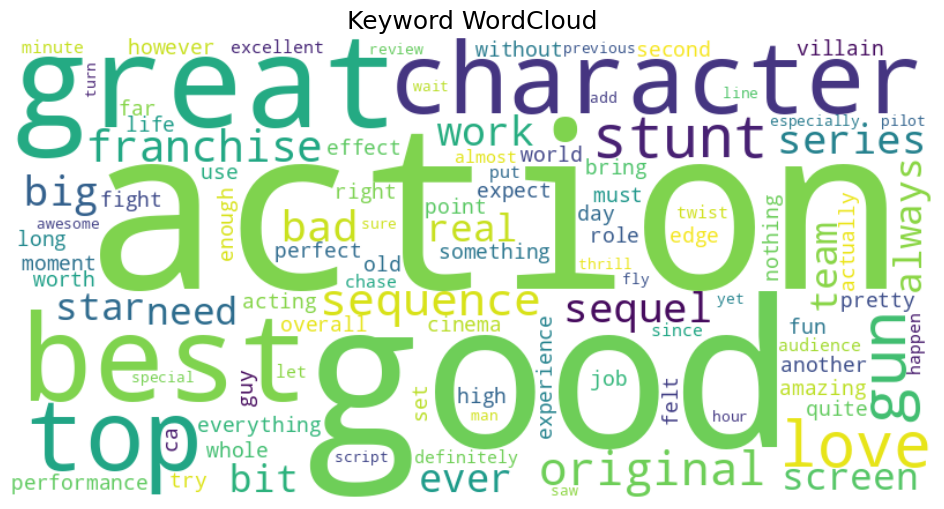


File: /kaggle/input/imdbreviews/TomCruise.json | Reviews: split_reviews | k: 20
action: 540.94
top: 505.15
good: 486.94
gun: 470.99
character: 429.42
great: 424.74
best: 389.25
stunt: 347.24
love: 299.52
team: 280.82
performance: 240.43
role: 239.28
star: 237.77
work: 211.17
always: 200.06
franchise: 192.37
big: 188.95
imf: 182.34
original: 181.01
sequence: 179.75


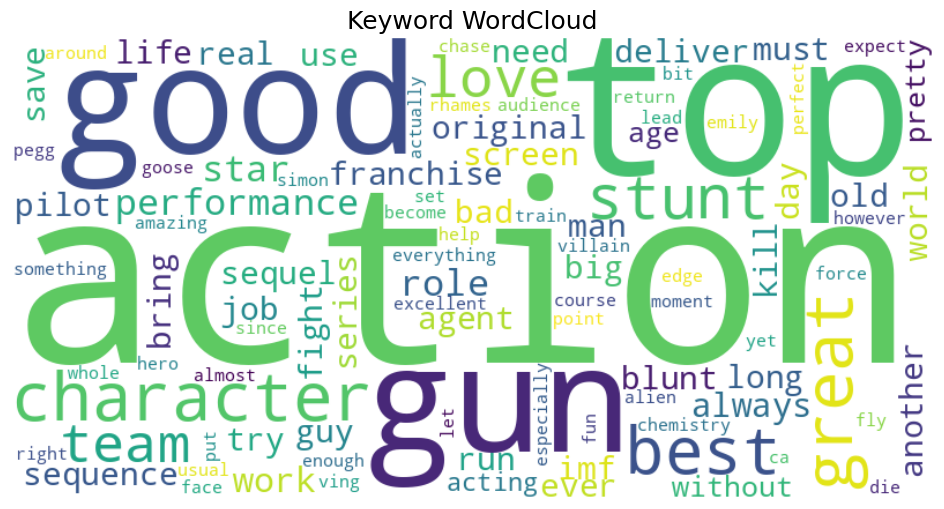


File: /kaggle/input/imdbreviews/MorganFreeman.json | Reviews: complete_reviews | k: 20


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['president'] not in stop_words.
  warnings.warn(


great: 242.43
best: 236.09
good: 232.20
character: 211.48
prison: 206.95
redemption: 189.38
performance: 185.91
life: 177.16
ever: 172.76
hope: 172.68
dark: 154.68
love: 136.78
role: 131.75
action: 124.41
begin: 117.66
man: 112.53
friendship: 109.04
christian: 107.57
ledger: 106.96
acting: 106.14


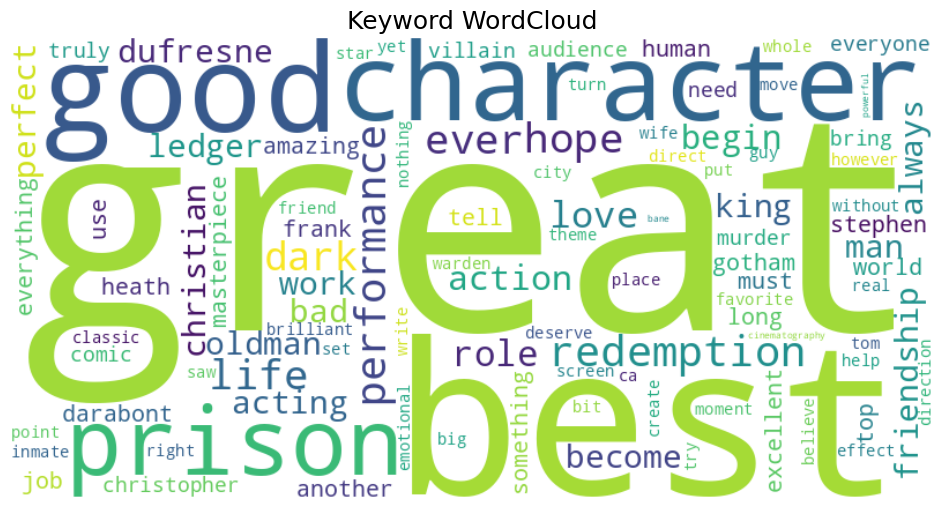


File: /kaggle/input/imdbreviews/MorganFreeman.json | Reviews: split_reviews | k: 20
performance: 288.79
great: 276.12
character: 232.24
good: 225.75
oldman: 225.29
prison: 225.23
best: 223.32
role: 202.81
life: 156.14
hope: 140.86
friendship: 136.90
friend: 125.28
inmate: 119.84
redemption: 112.61
man: 111.52
always: 110.51
christian: 107.44
ever: 104.62
love: 102.80
acting: 99.23


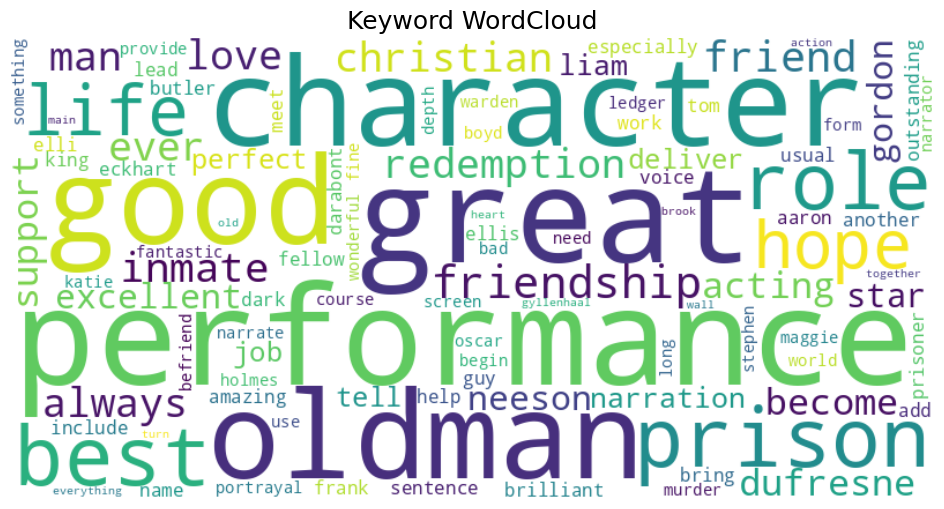

In [4]:
file_names = ["/kaggle/input/imdbreviews/TomCruise.json", "/kaggle/input/imdbreviews/MorganFreeman.json"]
kind_of_reviews = ["complete_reviews", "split_reviews"]
top_k = 20

for file_name in file_names:
    for kind_of_review in kind_of_reviews:
        ak = ActorKeywords(file_name, kind_of_review, top_k)
        print(f"File: {file_name} | Reviews: {kind_of_review} | k: {top_k}")
        ak.process_reviews()
        top_k_keywords = ak.get_top_k_keywords()
        for word, score in top_k_keywords:
            print(f"{word}: {score:.2f}")
        ak.change_top_k(100)
        top_k_keywords = ak.get_top_k_keywords()
        ak.plot_wordcloud(top_k_keywords)
        print()